In [23]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os
from joblib import Parallel, delayed
from scipy.sparse import csr_matrix

In [24]:
folder_path_83 = 'C:/Users/ricca/OneDrive/università/BAINSA/ESN/network_architecture/folder_path_83'
folder_path_129 = 'C:/Users/ricca/OneDrive/università/BAINSA/ESN/network_architecture/folder_path_129'
folder_path_234 = 'C:/Users/ricca/OneDrive/università/BAINSA/ESN/network_architecture/folder_path_234'
folder_path_463 = 'C:/Users/ricca/OneDrive/università/BAINSA/ESN/network_architecture/folder_path_463'
folder_path_1015 = 'C:/Users/ricca/OneDrive/università/BAINSA/ESN/network_architecture/folder_path_1015'
averaged_1015 = 'C:/Users/ricca/OneDrive/università/BAINSA/ESN/network_architecture/folder_path_average.graphml'

In [25]:
# Parameters
dt = 0.01  # Time step
T = 10  # Total simulation time (short time)
time_steps = int(T / dt)
n_trials = 10  # Number of trials for averaging
J_values = np.linspace(0, 8, 20)  # Range of J values

In [26]:
# Helper functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x)) - 0.5

def euler_method(r, A, dt, J):
    inputs = A.dot(r)  # Use sparse matrix multiplication
    return r + dt * (-r + sigmoid(inputs))

# def create_matrix(folder_path, J):
#     graphml_files = [f for f in os.listdir(folder_path) if f.endswith('.graphml')]
#     graphs = []
#     for file in graphml_files:
#         file_path = os.path.join(folder_path, file)
#         graph = nx.read_graphml(file_path)
#         graphs.append(graph)
    
#     matrices = []
#     for graph in graphs:
#         adj_matrix = nx.adjacency_matrix(graph, weight="d11").todense()
#         avg_fibers = np.mean(adj_matrix[adj_matrix > 0])  # normalise by average fibers
#         scaled_adj_matrix = J * adj_matrix / avg_fibers  # scale and normalise
#         matrices.append(scaled_adj_matrix)
#     return matrices

def create_matrix(folder_path, J):
    graphml_files = [f for f in os.listdir(folder_path) if f.endswith('.graphml')]
    graphs = []
    for file in graphml_files:
        file_path = os.path.join(folder_path, file)
        graph = nx.read_graphml(file_path)
        graphs.append(graph)
    
    matrices = []
    for graph in graphs:
        adj_matrix = nx.adjacency_matrix(graph, weight="d11")
        avg_fibers = np.mean(adj_matrix.data)  # Use sparse matrix data
        scaled_adj_matrix = J * adj_matrix / avg_fibers
        matrices.append(csr_matrix(scaled_adj_matrix))  # Store as sparse matrix
    return matrices

def run_trial(matrices, N, dt, J, time_steps):
    A = matrices[np.random.randint(len(matrices))]
    r = np.random.uniform(0, 1, (N,))
    rates = np.zeros((time_steps, N))
    for t in range(time_steps):
        rates[t] = r
        r = euler_method(r, A, dt, J)
    return np.mean(rates[-1]), np.var(rates[-1])

C:\Users\ricca\AppData\Local\Temp\ipykernel_20228\927909785.py:35: FutureWarning: adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.
  adj_matrix = nx.adjacency_matrix(graph, weight="d11")


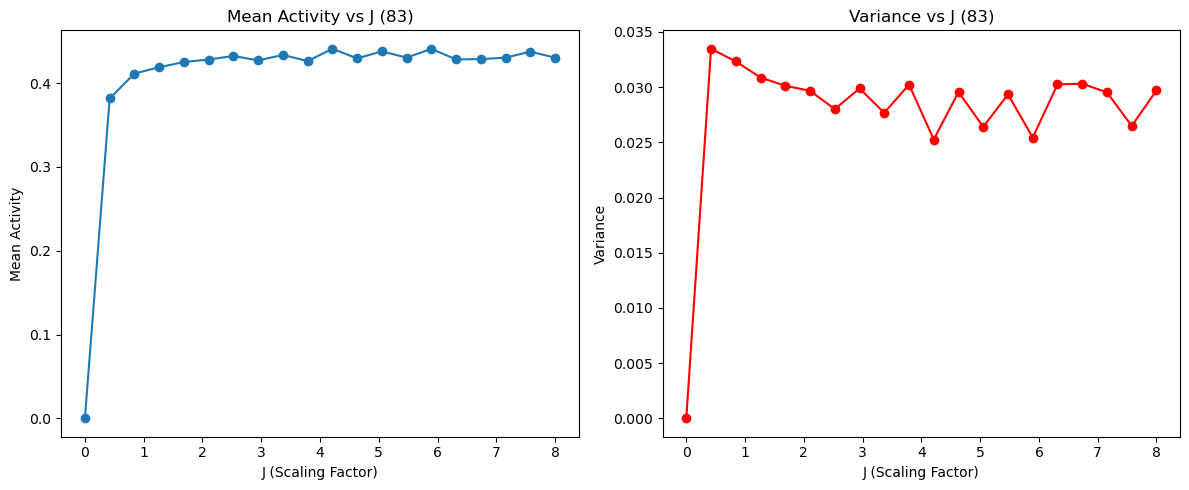

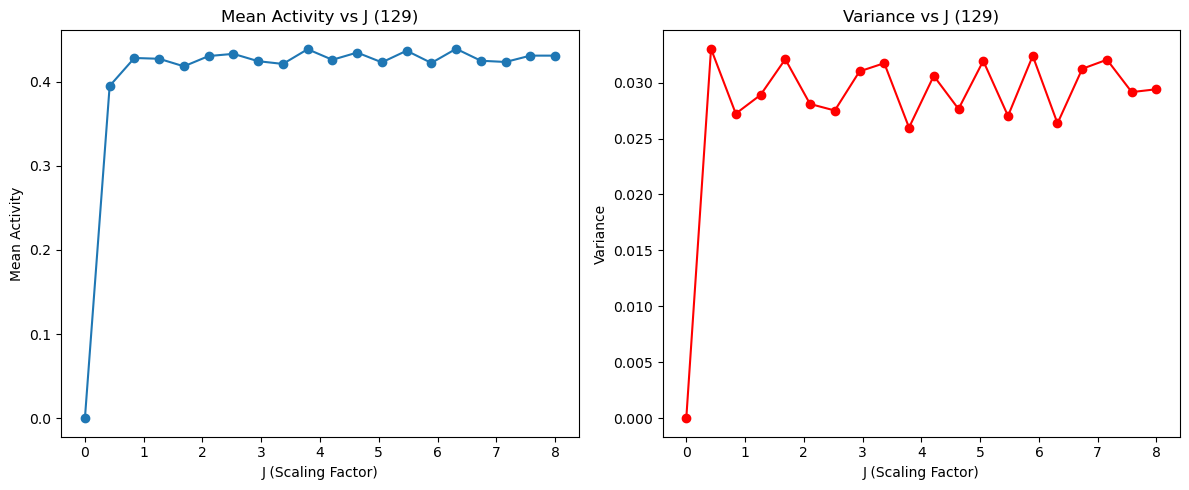

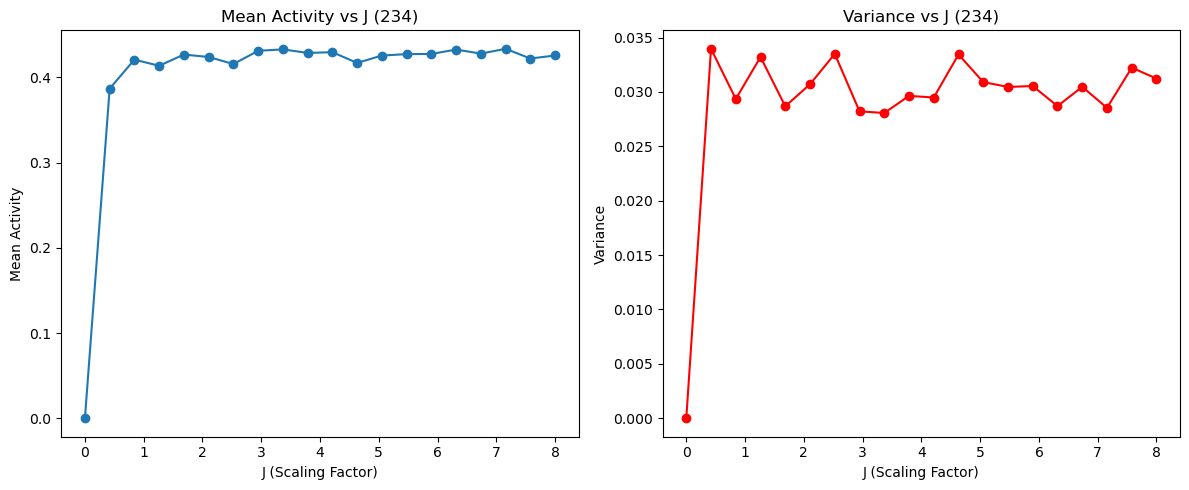

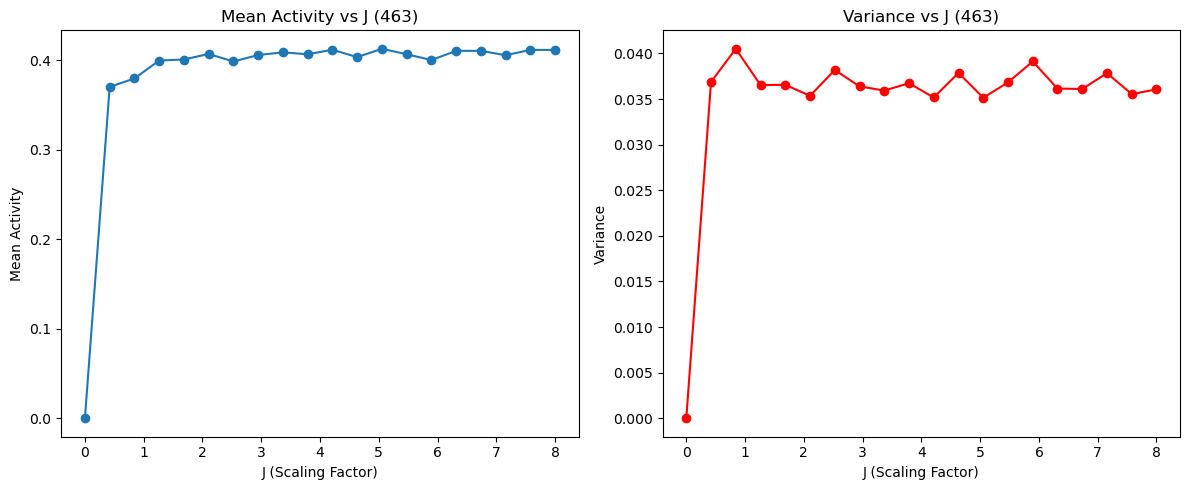

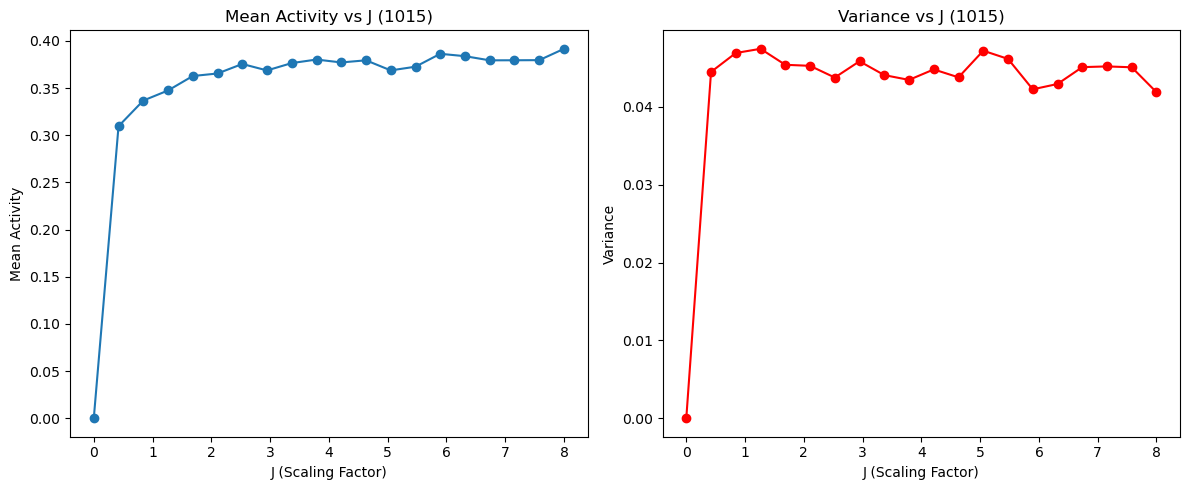

In [27]:
# Storage for results


folders_paths={
    "83": folder_path_83,
    "129": folder_path_129,
    "234":folder_path_234,
    "463":folder_path_463,
    "1015":folder_path_1015
}

results = {network_name: {"mean_activity": [], "var_activity": []} for network_name in folders_paths.keys()}

# Iterate over network types and J values

trial_means = np.zeros(n_trials)
trial_vars = np.zeros(n_trials)
# Iterate over network types and J values
for folder_name, folder_path in folders_paths.items():
    for J in J_values:
        matrices = create_matrix(folder_path, J)
        results_list = Parallel(n_jobs=-1)(
            delayed(run_trial)(matrices, int(folder_name), dt, J, time_steps) for _ in range(n_trials)
        )
        trial_means, trial_vars = zip(*results_list)
        results[folder_name]["mean_activity"].append(np.mean(trial_means))
        results[folder_name]["var_activity"].append(np.mean(trial_vars))



# for folder_name, folder_path in folders_paths.items():
#     for J in J_values:
#         trial_means = []
#         trial_vars = []
#         for _ in range(n_trials):
#             # Create the network adjacency matrix
#             N=int(folder_name)
#             # A = create_matrix(folder_pa, J)
#             matrices = create_matrix(folder_path, J)  # Get the list of matrices
#             A = matrices[np.random.randint(len(matrices))]  # Randomly select one matrix

#             # Initialize rates
#             r = np.random.uniform(0, 1, N)
#             rates = np.zeros((time_steps, N))

#             # Simulate dynamics
#             for t in range(time_steps):
#                 rates[t] = r
#                 r = euler_method(r, A, dt, J)

#             # Compute mean and variance at the final time step
#             trial_means.append(np.mean(rates[-1]))
#             trial_vars.append(np.var(rates[-1]))

#         # Average over trials
#         results[folder_name]["mean_activity"].append(np.mean(trial_means))
#         results[folder_name]["var_activity"].append(np.mean(trial_vars))

            
# Plotting results
for folder_name in folders_paths:
    mean_activity = results[folder_name]["mean_activity"]
    var_activity = results[folder_name]["var_activity"]

    plt.figure(figsize=(12, 5))

    # Mean activity vs J
    plt.subplot(1, 2, 1)
    plt.plot(J_values, mean_activity, marker='o')
    plt.title(f'Mean Activity vs J ({folder_name})')
    plt.xlabel('J (Scaling Factor)')
    plt.ylabel('Mean Activity')

    # Variance vs J
    plt.subplot(1, 2, 2)
    plt.plot(J_values, var_activity, marker='o', color='r')
    plt.title(f'Variance vs J ({folder_name})')
    plt.xlabel('J (Scaling Factor)')
    plt.ylabel('Variance')

    plt.tight_layout()
    plt.show()